In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#roc and auc score
from sklearn.datasets  import make_classification

In [6]:
from sklearn.model_selection import train_test_split
X,y=make_classification(n_samples=2000,n_classes=2,weights=[1,1],random_state=1)

In [3]:
X.shape

(2000, 20)

In [4]:
y

array([0, 0, 0, ..., 1, 1, 0])

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

In [9]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

## Random Forest

In [13]:
#Applying RandomForest Classification
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier()
rf_model.fit(X_train,y_train)
ytrain_pred=rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train,ytrain_pred[:,1])))
ytest_pred=rf_model.predict_proba(X_test)
print('RF test roc-auc: {}.'.format(roc_auc_score(y_test,ytest_pred[:,1])))

RF train roc-auc: 1.0
RF test roc-auc: 0.9820833333333333.


In [19]:
ytest_pred , ytrain_pred



(array([[0. , 1. ],
        [1. , 0. ],
        [0.2, 0.8],
        ...,
        [0. , 1. ],
        [0.8, 0.2],
        [0.2, 0.8]]),
 array([[1. , 0. ],
        [1. , 0. ],
        [0. , 1. ],
        ...,
        [0.6, 0.4],
        [1. , 0. ],
        [0.4, 0.6]]))

## Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
log_classifier=LogisticRegression()
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Logistic train roc-auc: 0.9863589331232614
Logistic test roc-auc: 0.9885777777777777


## Adaboost Classifier

In [15]:
from sklearn.ensemble import AdaBoostClassifier
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Adaboost train roc-auc: 0.9975081174960356
Adaboost test roc-auc: 0.9826111111111111


## KNN Classification

In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Adaboost train roc-auc: 0.981670071491109
Adaboost test roc-auc: 0.9426111111111111


##### Now we will focus on selecting the best threshold for the model accuracy of ROC Curve 

In [20]:
pred=[]
for model in [rf_model,log_classifier,ada_classifier,knn_classifier]:
    pred.append(pd.Series(model.predict_proba(X_test)[:,1]))
final_prediction=pd.concat(pred,axis=1).mean(axis=1)
print('Ensemble test roc-auc: {}'.format(roc_auc_score(y_test,final_prediction)))

Ensemble test roc-auc: 0.984488888888889


In [29]:
df=pd.DataFrame(pred)
df.head

In [21]:

pd.concat(pred,axis=1)

,0,1,2,3
0,0.99,0.991873,0.559186,1.0
1,0.02,0.000008,0.463282,0.0
2,0.97,0.966763,0.538202,0.8
3,0.96,0.761896,0.509875,0.8
4,0.55,0.779209,0.490344,0.4
...,...,...,...,...
595,0.01,0.024263,0.461121,0.0
596,0.04,0.000003,0.441377,0.0
597,1.00,0.984400,0.532403,1.0
598,0.02,0.001157,0.441720,0.2


In [22]:
final_prediction


0      0.885265
1      0.120823
2      0.818741
3      0.757943
4      0.554888
         ...   
595    0.123846
596    0.120345
597    0.879201
598    0.165719
599    0.837358
Length: 600, dtype: float64

#### Calculate the ROc Curve


In [23]:
fpr, tpr, thresholds = roc_curve(y_test, final_prediction)
thresholds

array([       inf, 0.9134408 , 0.90938112, 0.90827496, 0.80546059,
       0.80409566, 0.80009577, 0.79806746, 0.78158868, 0.78077862,
       0.76797657, 0.76536546, 0.72177705, 0.72133029, 0.7184278 ,
       0.71639901, 0.66788731, 0.66743002, 0.5972633 , 0.59670593,
       0.59627713, 0.58983761, 0.58703473, 0.58547279, 0.56392151,
       0.55724303, 0.55488822, 0.54403224, 0.51104489, 0.49366162,
       0.44961178, 0.43525301, 0.42699699, 0.40235054, 0.4013691 ,
       0.34391699, 0.34335998, 0.25108474, 0.24877731, 0.24826593,
       0.24147529, 0.21101022, 0.20851676, 0.117975  , 0.11783511,
       0.10498954])

In [24]:
from sklearn.metrics import accuracy_score
accuracy_ls = []
for thres in thresholds:
    y_pred = np.where(final_prediction>thres,1,0)
    accuracy_ls.append(accuracy_score(y_test, y_pred, normalize=True))
    
accuracy_ls = pd.concat([pd.Series(thresholds), pd.Series(accuracy_ls)],
                        axis=1)
accuracy_ls.columns = ['thresholds', 'accuracy']
accuracy_ls.sort_values(by='accuracy', ascending=False, inplace=True)
accuracy_ls.head()

,thresholds,accuracy
30,0.449612,0.960000
31,0.435253,0.958333
29,0.493662,0.958333
32,0.426997,0.956667
28,0.511045,0.956667


In [25]:
accuracy_ls


,thresholds,accuracy
30,0.449612,0.960000
31,0.435253,0.958333
29,0.493662,0.958333
32,0.426997,0.956667
28,0.511045,0.956667
33,0.402351,0.951667
27,0.544032,0.951667
34,0.401369,0.950000
26,0.554888,0.950000
25,0.557243,0.950000


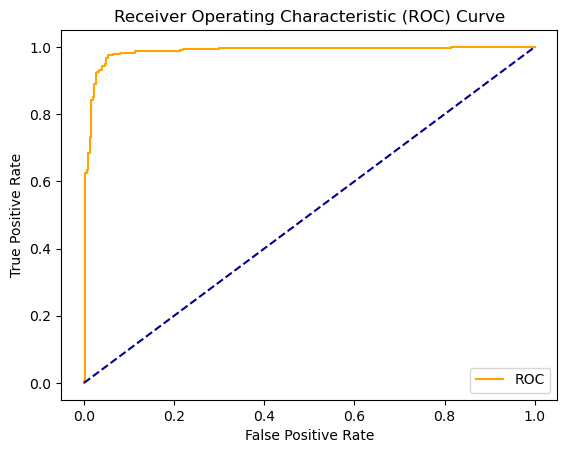

In [26]:

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()
plot_roc_curve(fpr,tpr)